<a href="https://colab.research.google.com/github/kiming7/machine-learning/blob/main/rizkmah_lailatul_SVR%2CRF%2CDT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================
# 1. IMPORT LIBRARY
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# ===============================
# 2. LOAD DATA
# ===============================
data = pd.read_excel('/content/AirQualityUCI.xlsx')
print(data.head())

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00       150  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25       112   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00        88   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50        80   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25        51   6.518224   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0        1045.50    166.0       1056.25    113.0       1692.00      1267.50   
1         954.75    103.0       1173.75     92.0       1558.75       972.25   
2         939.25    131.0       1140.00    114.0       1554.50      1074.00   
3         948.25    172.0       1092.00    122.0       1583.75      1203.25   
4         835.50    131.0       1205.00    116.0       1490.00      1110.00   

       T         RH        AH  
0  13.60  48.875001  0.757754  
1  13.30  47.700000  0.725487  
2  11.90  53.975000 

In [ ]:
# ===============================
# 3. DATA UNDERSTANDING
# ===============================
print("\n===== INFO DATA =====")
print(data.info())

print("\n===== DESKRIPSI DATA =====")
print(data.describe())




===== INFO DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
dty

In [ ]:
# ===============================
# 4. DATA PREPROCESSING
# ===============================
data.replace(-200, np.nan, inplace=True)
data.dropna(inplace=True)
data.drop(columns=['Date', 'Time'], inplace=True)

print("\n===== TABEL MISSING VALUE =====")
missing = data.isnull().sum()
missing_percent = (missing / len(data)) * 100

missing_table = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_percent
})
print(missing_table)



===== TABEL MISSING VALUE =====
               Jumlah Missing  Persentase (%)
CO(GT)                      0             0.0
PT08.S1(CO)                 0             0.0
NMHC(GT)                    0             0.0
C6H6(GT)                    0             0.0
PT08.S2(NMHC)               0             0.0
NOx(GT)                     0             0.0
PT08.S3(NOx)                0             0.0
NO2(GT)                     0             0.0
PT08.S4(NO2)                0             0.0
PT08.S5(O3)                 0             0.0
T                           0             0.0
RH                          0             0.0
AH                          0             0.0


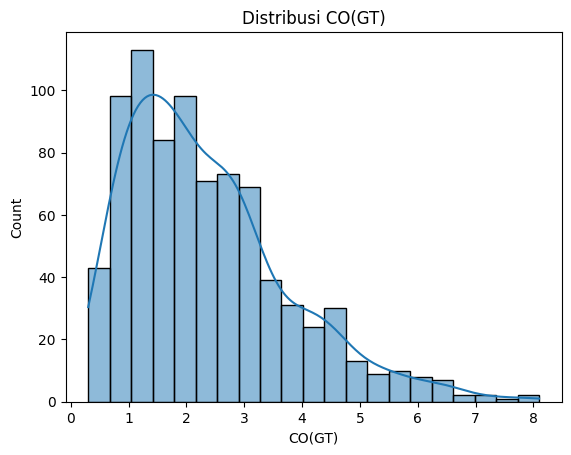

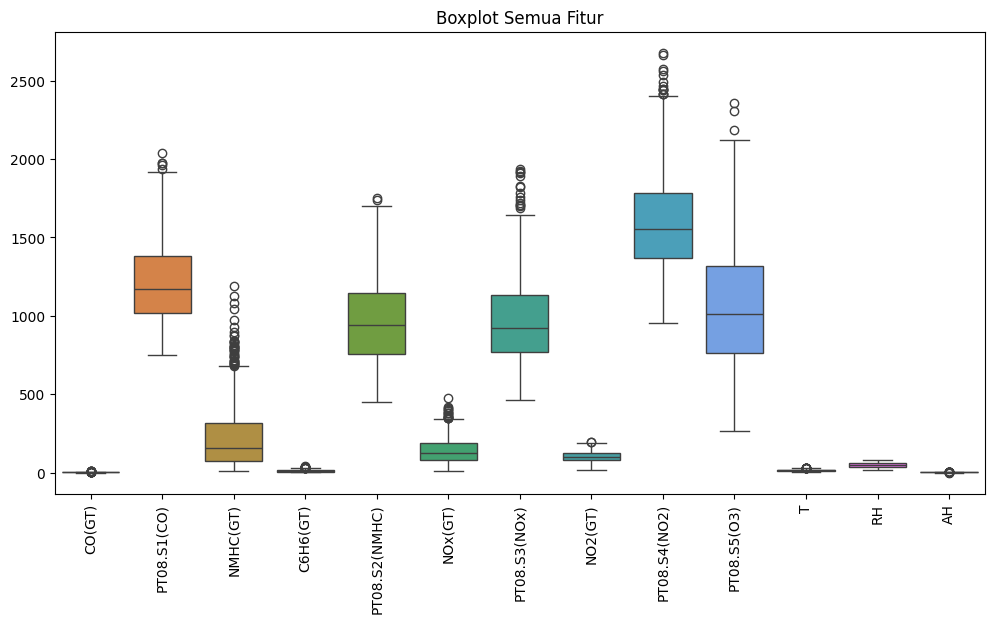

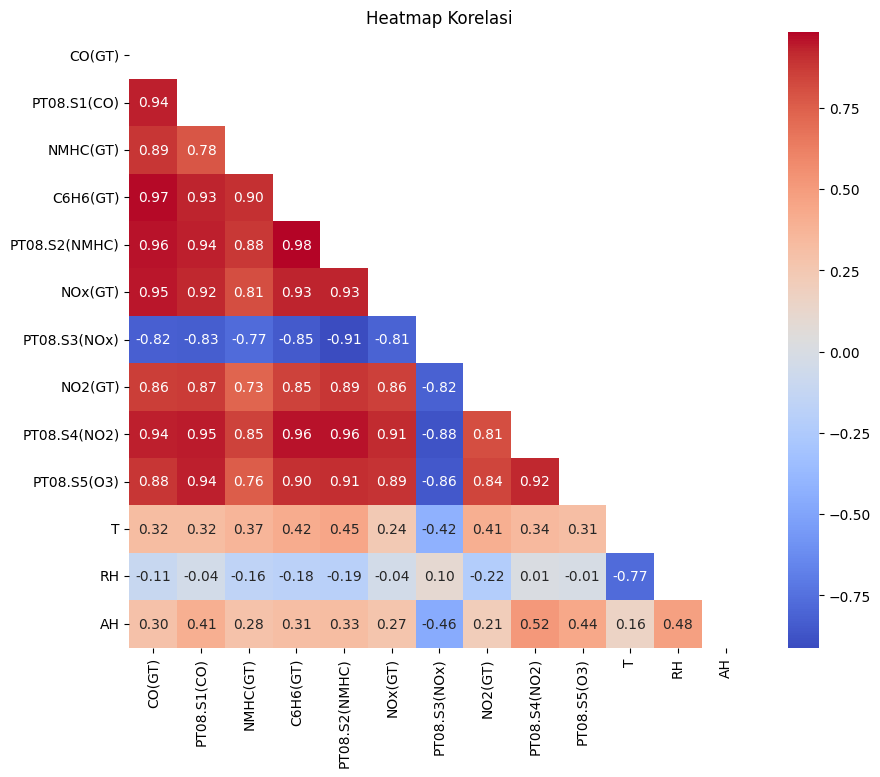

In [ ]:
# ===============================
# 5. EDA
# ===============================
plt.figure()
sns.histplot(data['CO(GT)'], kde=True)
plt.title('Distribusi CO(GT)')
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.title("Boxplot Semua Fitur")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(10,8))
corr_matrix = data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap Korelasi")
plt.show()


In [ ]:
# ===============================
# 6. FITUR & TARGET
# ===============================
X = data.drop('CO(GT)', axis=1)
y = data['CO(GT)']


In [ ]:
# ===============================
# 7. FUNGSI EVALUASI
# ===============================
def evaluasi(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2


In [ ]:
# ===============================
# 8. DATA SPLITTING
# ===============================
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}


In [ ]:
# ===============================
# 9. MODELING + TUNING
# ===============================

hasil = []
train_scores = []
test_scores = []

# untuk model terbaik
best_r2_global = -999
best_model_obj = None
best_model_info = None

for nama_split, test_size in splits.items():

    print("\n==============================")
    print(f"        SPLIT {nama_split}")
    print("==============================")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ================= MODEL DEFAULT =================
    print("\n--- MODEL DEFAULT ---")

    # RF Default
    rf_default = RandomForestRegressor()
    rf_default.fit(X_train, y_train)
    r2_rf = r2_score(y_test, rf_default.predict(X_test))
    print(f"RF Default R2: {r2_rf:.4f}")

    # DT Default
    dt_default = DecisionTreeRegressor()
    dt_default.fit(X_train, y_train)
    r2_dt = r2_score(y_test, dt_default.predict(X_test))
    print(f"DT Default R2: {r2_dt:.4f}")

    # SVR Default
    svr_default = SVR()
    svr_default.fit(X_train_scaled, y_train)
    r2_svr = r2_score(y_test, svr_default.predict(X_test_scaled))
    print(f"SVR Default R2: {r2_svr:.4f}")

    # ================= MODEL TUNING =================
    print("\n--- MODEL TUNING ---")

    # RF Tuning
    rf = GridSearchCV(
        RandomForestRegressor(),
        {'n_estimators': [50, 100], 'max_depth': [5, 10, None]},
        cv=3
    )
    rf.fit(X_train, y_train)
    train_r2_rf = rf.score(X_train, y_train)
    test_r2_rf = rf.score(X_test, y_test)
    y_pred_rf = rf.predict(X_test)
    mae_rf, mse_rf, rmse_rf, r2_rf_tuning = evaluasi(y_test, y_pred_rf)
    print(f"RF Tuning R2: {r2_rf_tuning:.4f}")

    hasil.append(["Random Forest", nama_split, mae_rf, mse_rf, rmse_rf, r2_rf_tuning])
    train_scores.append(["Random Forest", nama_split, train_r2_rf])
    test_scores.append(["Random Forest", nama_split, test_r2_rf])

    if r2_rf_tuning > best_r2_global:
        best_r2_global = r2_rf_tuning
        best_model_obj = rf
        best_model_info = ("Random Forest", nama_split)


    # DT Tuning
    dt = GridSearchCV(
        DecisionTreeRegressor(),
        {'max_depth': [5, 10, None], 'min_samples_split': [2, 5]},
        cv=3
    )
    dt.fit(X_train, y_train)
    train_r2_dt = dt.score(X_train, y_train)
    test_r2_dt = dt.score(X_test, y_test)
    y_pred_dt = dt.predict(X_test)
    mae_dt, mse_dt, rmse_dt, r2_dt_tuning = evaluasi(y_test, y_pred_dt)
    print(f"DT Tuning R2: {r2_dt_tuning:.4f}")

    hasil.append(["Decision Tree", nama_split, mae_dt, mse_dt, rmse_dt, r2_dt_tuning])
    train_scores.append(["Decision Tree", nama_split, train_r2_dt])
    test_scores.append(["Decision Tree", nama_split, test_r2_dt])

    if r2_dt_tuning > best_r2_global:
        best_r2_global = r2_dt_tuning
        best_model_obj = dt
        best_model_info = ("Decision Tree", nama_split)


    # SVR Tuning
    svr = GridSearchCV(
        SVR(),
        {'C': [1, 10], 'kernel': ['rbf', 'linear']},
        cv=3
    )
    svr.fit(X_train_scaled, y_train)
    train_r2_svr = svr.score(X_train_scaled, y_train)
    test_r2_svr = svr.score(X_test_scaled, y_test)
    y_pred_svr = svr.predict(X_test_scaled)
    mae_svr, mse_svr, rmse_svr, r2_svr_tuning = evaluasi(y_test, y_pred_svr)
    print(f"SVR Tuning R2: {r2_svr_tuning:.4f}")

    hasil.append(["SVR", nama_split, mae_svr, mse_svr, rmse_svr, r2_svr_tuning])
    train_scores.append(["SVR", nama_split, train_r2_svr])
    test_scores.append(["SVR", nama_split, test_r2_svr])

    if r2_svr_tuning > best_r2_global:
        best_r2_global = r2_svr_tuning
        best_model_obj = svr
        best_model_info = ("SVR", nama_split)



        SPLIT 70:30

--- MODEL DEFAULT ---
RF Default R2: 0.9696
DT Default R2: 0.9358
SVR Default R2: 0.9705

--- MODEL TUNING ---
RF Tuning R2: 0.9688
DT Tuning R2: 0.9331
SVR Tuning R2: 0.9723

        SPLIT 80:20

--- MODEL DEFAULT ---
RF Default R2: 0.9709
DT Default R2: 0.9450
SVR Default R2: 0.9688

--- MODEL TUNING ---
RF Tuning R2: 0.9696
DT Tuning R2: 0.9409
SVR Tuning R2: 0.9716

        SPLIT 90:10

--- MODEL DEFAULT ---
RF Default R2: 0.9654
DT Default R2: 0.9416
SVR Default R2: 0.9752

--- MODEL TUNING ---
RF Tuning R2: 0.9612
DT Tuning R2: 0.9332
SVR Tuning R2: 0.9841


In [ ]:
# ===============================
# 10. HASIL MODEL
# ===============================
hasil_df = pd.DataFrame(hasil, columns=['Model','Split','MAE','MSE','RMSE','R2'])
train_df = pd.DataFrame(train_scores, columns=['Model','Split','Train R2'])
test_df = pd.DataFrame(test_scores, columns=['Model','Split','Test R2'])

print("\n===== HASIL MODEL =====")
print(hasil_df)



===== HASIL MODEL =====
           Model  Split       MAE       MSE      RMSE        R2
0  Random Forest  70:30  0.171896  0.059737  0.244411  0.968770
1  Decision Tree  70:30  0.246389  0.127994  0.357763  0.933085
2            SVR  70:30  0.170033  0.053050  0.230326  0.972265
3  Random Forest  80:20  0.175928  0.063314  0.251623  0.969584
4  Decision Tree  80:20  0.235885  0.123038  0.350768  0.940894
5            SVR  80:20  0.175476  0.059090  0.243084  0.971614
6  Random Forest  90:10  0.181945  0.068157  0.261068  0.961248
7  Decision Tree  90:10  0.257579  0.117494  0.342774  0.933196
8            SVR  90:10  0.124363  0.027932  0.167128  0.984119


In [ ]:
# ===============================
# 11. TARGET R2
# ===============================
target_r2 = 0.90
hasil_df['Status'] = hasil_df['R2'].apply(
    lambda x: "Tercapai ✅" if x >= target_r2 else "Belum ❌"
)

print("\n===== TARGET R2 =====")
print(hasil_df[['Model','Split','R2','Status']])



===== TARGET R2 =====
           Model  Split        R2      Status
0  Random Forest  70:30  0.968770  Tercapai ✅
1  Decision Tree  70:30  0.933085  Tercapai ✅
2            SVR  70:30  0.972265  Tercapai ✅
3  Random Forest  80:20  0.969584  Tercapai ✅
4  Decision Tree  80:20  0.940894  Tercapai ✅
5            SVR  80:20  0.971614  Tercapai ✅
6  Random Forest  90:10  0.961248  Tercapai ✅
7  Decision Tree  90:10  0.933196  Tercapai ✅
8            SVR  90:10  0.984119  Tercapai ✅


In [ ]:
# ===============================
# 12. PIVOT TABLE
# ===============================
train_pivot = train_df.pivot(index='Model', columns='Split', values='Train R2')
test_pivot = test_df.pivot(index='Model', columns='Split', values='Test R2')

print("\n===== TRAIN R2 =====")
print(train_pivot)

print("\n===== TEST R2 =====")
print(test_pivot)



===== TRAIN R2 =====
Split             70:30     80:20     90:10
Model                                      
Decision Tree  0.999358  0.997330  0.973695
Random Forest  0.995358  0.995475  0.994990
SVR            0.974725  0.974610  0.992186

===== TEST R2 =====
Split             70:30     80:20     90:10
Model                                      
Decision Tree  0.933085  0.940894  0.933196
Random Forest  0.968770  0.969584  0.961248
SVR            0.972265  0.971614  0.984119


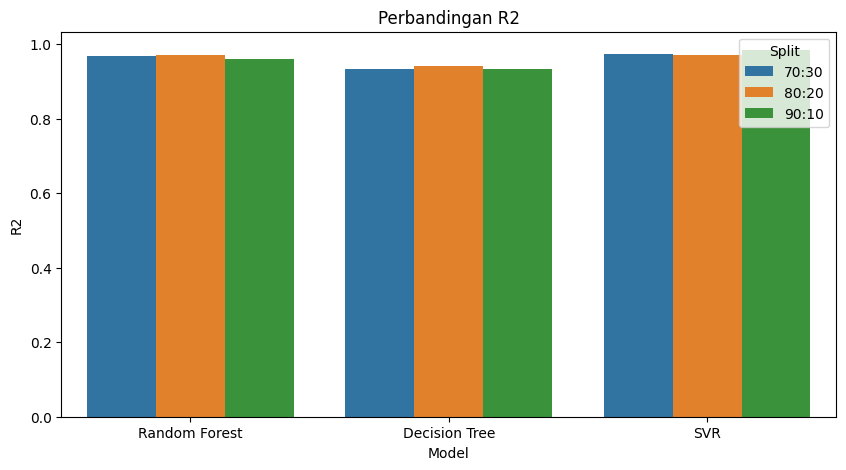

In [ ]:
# ===============================
# 13. VISUALISASI
# ===============================
plt.figure(figsize=(10,5))
sns.barplot(data=hasil_df, x='Model', y='R2', hue='Split')
plt.title('Perbandingan R2')
plt.show()


In [ ]:
# ===============================
# 14. MODEL TERBAIK
# ===============================
print("\n===== MODEL TERBAIK =====")
# Check if best_model_info is not None before accessing its elements
if best_model_info:
    print(f"Model: {best_model_info[0]}")
    print(f"Split: {best_model_info[1]}")
    print(f"R2: {best_r2_global:.4f}")

    joblib.dump(best_model_obj, 'model_terbaik.pkl')
    print("Model berhasil disimpan!")
else:
    print("No best model found.")



===== MODEL TERBAIK =====
Model: SVR
Split: 90:10
R2: 0.9841
Model berhasil disimpan!


In [ ]:
# ===============================
# 15. INFERENCE
# ===============================


# Load the best model
best_model = joblib.load('model_terbaik.pkl')
print("Best model loaded successfully!")

Best model loaded successfully!


In [ ]:
# Get sample input data (e.g., first row of X)
sample_input = X.head(1)

# Re-initialize and fit the scaler on X_train (from the last split, which was 90:10)
# This ensures the scaler has the same state as when the best SVR model was trained.
X_train_for_scaler, _, y_train_for_scaler, _ = train_test_split(X, y, test_size=splits["90:10"], random_state=42)
scaler_for_prediction = StandardScaler()
scaler_for_prediction.fit(X_train_for_scaler)

# Scale the sample input
sample_input_scaled = scaler_for_prediction.transform(sample_input)

print("Sample Input (original):")
print(sample_input)
print("\nSample Input (scaled):")
print(sample_input_scaled)

Sample Input (original):
   PT08.S1(CO)  NMHC(GT)   C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  \
0       1360.0     150.0  11.881723         1045.5    166.0       1056.25   

   NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T         RH        AH  
0    113.0        1692.0       1267.5  13.6  48.875001  0.757754  

Sample Input (scaled):
[[ 0.6250649  -0.39009554  0.14575769  0.29617584  0.27048556  0.33979359
   0.40674286  0.30021308  0.54874384 -0.42199614 -0.00561333 -0.41615733]]


In [ ]:
# Make a prediction
prediction = best_model.predict(sample_input_scaled)

print(f"Predicted CO(GT) for the sample input: {prediction[0]:.4f}")

Predicted CO(GT) for the sample input: 2.7001
